In [24]:

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [25]:
# Import numerical computation library
import numpy as np

# Import pandas for dataset handling
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import seaborn for advanced visualization
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

In [26]:
from google.colab import files
df = files.upload()

Saving ML-CaseStudy3-Dataset.csv to ML-CaseStudy3-Dataset (1).csv


In [28]:
#Read exel file
df = pd.read_csv('ML-CaseStudy3-Dataset.csv')
# Display first  rows
df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


In [29]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:\n", df.columns)

# Display data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (2000, 19)

Column Names:
 Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

Data Types:

case_id                   object
country                   object
region                    object
report_date               object
virus_strain              object
transmission_type         object
exposure_source           object
patient_age                int64
gender                    object
symptoms                  object
hospitalization           object
fatality                  object
recovery_days            float64
temperature_celsius      float64
humidity_percent         float64
rodent_presence_index      int64
quarantine_days            int64
populat

In [30]:
print(df.isnull().sum())

case_id                    0
country                    0
region                     0
report_date                0
virus_strain               0
transmission_type          0
exposure_source            0
patient_age                0
gender                     0
symptoms                   0
hospitalization            0
fatality                   0
recovery_days            155
temperature_celsius        0
humidity_percent           0
rodent_presence_index      0
quarantine_days            0
population_density         0
air_quality_index          0
dtype: int64


In [31]:
df.describe()

,patient_age,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
count,2000.000000,1845.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,45.196000,26.293225,24.174850,64.623400,5.494500,10.551500,4968.62350,159.701000
std,19.115001,11.273430,5.981896,17.466002,2.868115,6.369037,2961.87065,81.034152
min,12.000000,7.000000,4.600000,35.000000,1.000000,0.000000,54.00000,20.000000
25%,29.000000,16.000000,20.200000,49.500000,3.000000,5.000000,2341.25000,89.000000
50%,46.000000,27.000000,24.200000,64.550000,5.000000,11.000000,4952.50000,162.000000
75%,62.000000,36.000000,28.000000,79.825000,8.000000,16.000000,7648.75000,231.250000
max,78.000000,45.000000,47.600000,95.000000,10.000000,21.000000,9999.00000,300.000000


In [32]:
 df.dropna(inplace=True)

In [33]:
print(df.isnull().sum())

case_id                  0
country                  0
region                   0
report_date              0
virus_strain             0
transmission_type        0
exposure_source          0
patient_age              0
gender                   0
symptoms                 0
hospitalization          0
fatality                 0
recovery_days            0
temperature_celsius      0
humidity_percent         0
rodent_presence_index    0
quarantine_days          0
population_density       0
air_quality_index        0
dtype: int64


In [34]:
Categorical_col = df.select_dtypes(include = 'object').columns
Categorical_col

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'gender', 'symptoms',
       'hospitalization', 'fatality'],
      dtype='object')

In [37]:
# Selecting numerical features only(country, region, report_date, virus_strain, transmission_type, exposure_source)
X = df.drop(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'gender', 'symptoms',
       'hospitalization', 'fatality'],
      axis=1)

# Display first 5 rows
X.head()

,patient_age,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,26,22.0,27.0,78.9,7,1,538,67
1,41,41.0,23.2,70.9,3,13,5624,162
2,39,31.0,22.6,38.5,8,17,2095,213
3,49,11.0,22.6,87.0,7,8,7478,206
4,59,24.0,33.5,36.2,8,12,4472,132


In [38]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Scale the dataset
X_scaled = scaler.fit_transform(X)

# Display scaled data shape
print(X_scaled.shape)

(1845, 8)


In [ ]:
# Import KMeans
from sklearn.cluster import KMeans

# Create empty list for WCSS
wcss = []

# Run loop for different k values
for i in range(1, 11):

    # Create KMeans model
    kmeans = KMeans(n_clusters=i, random_state=42)

    # Fit model
    kmeans.fit(X_scaled)

    # Append inertia value
    wcss.append(kmeans.inertia_)

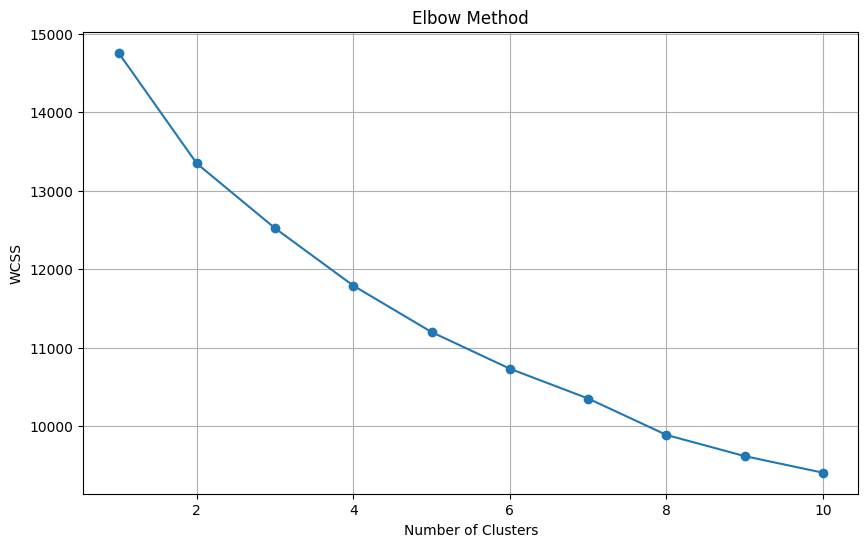

In [ ]:
# Plot elbow graph
plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# Create KMeans model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column into dataset
df['Cluster'] = clusters

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data
pca_components = pca.fit_transform(X_scaled)

# Create new dataframe
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])

# Add cluster column
pca_df['Cluster'] = clusters

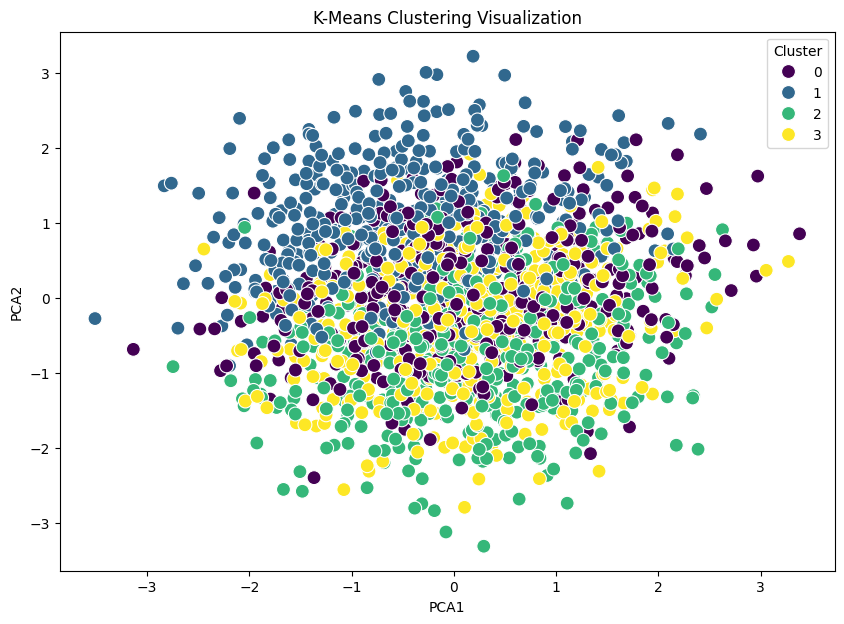

In [ ]:
# Plot clusters
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

plt.title('K-Means Clustering Visualization')

plt.show()

In [ ]:
# Cluster-wise average values
cluster_mean = df.groupby('Cluster').mean(numeric_only=True)

# Display analysis
print(cluster_mean)

         patient_age  recovery_days  temperature_celsius  humidity_percent  \
Cluster                                                                      
0          45.195946      26.900901            25.219144         47.619595   
1          40.002088      26.862213            20.957411         60.415031   
2          48.673160      26.242424            24.117965         79.577706   
3          47.967391      25.165217            26.386739         70.578696   

         rodent_presence_index  quarantine_days  population_density  \
Cluster                                                               
0                     4.954955         9.594595         5694.216216   
1                     7.638831        13.258873         4395.075157   
2                     5.599567        11.577922         4928.432900   
3                     3.910870         7.658696         4792.719565   

         air_quality_index  
Cluster                     
0               217.853604  
1               1

In [ ]:
# CLUSTER CENTERS
# ----------------------------------------

# Display cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

# Add cluster number
cluster_centers.index.name = 'Cluster Number'

# Display cluster centers
print("Cluster Centers:\n")
print(cluster_centers)

Cluster Centers:

                patient_age  recovery_days  temperature_celsius  \
Cluster Number                                                    
0                 45.195946      26.900901            25.219144   
1                 40.002088      26.862213            20.957411   
2                 48.673160      26.242424            24.117965   
3                 47.967391      25.165217            26.386739   

                humidity_percent  rodent_presence_index  quarantine_days  \
Cluster Number                                                             
0                      47.619595               4.954955         9.594595   
1                      60.415031               7.638831        13.258873   
2                      79.577706               5.599567        11.577922   
3                      70.578696               3.910870         7.658696   

                population_density  air_quality_index  
Cluster Number                                         
0         

In [ ]:
# PCA CLUSTER VISUALIZATION
# ===========================================

# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data into 2 dimensions
pca_components = pca.fit_transform(X_scaled)

# Create dataframe for PCA
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PCA1', 'PCA2']
)

# Add cluster labels
pca_df['Cluster'] = clusters

# Display first 5 rows
print(pca_df.head())

       PCA1      PCA2  Cluster
0 -0.602081 -0.118942        3
1 -0.886987 -0.930300        2
2 -0.748802  0.800346        1
3  1.088019  0.189913        2
4  1.354481  0.697991        0


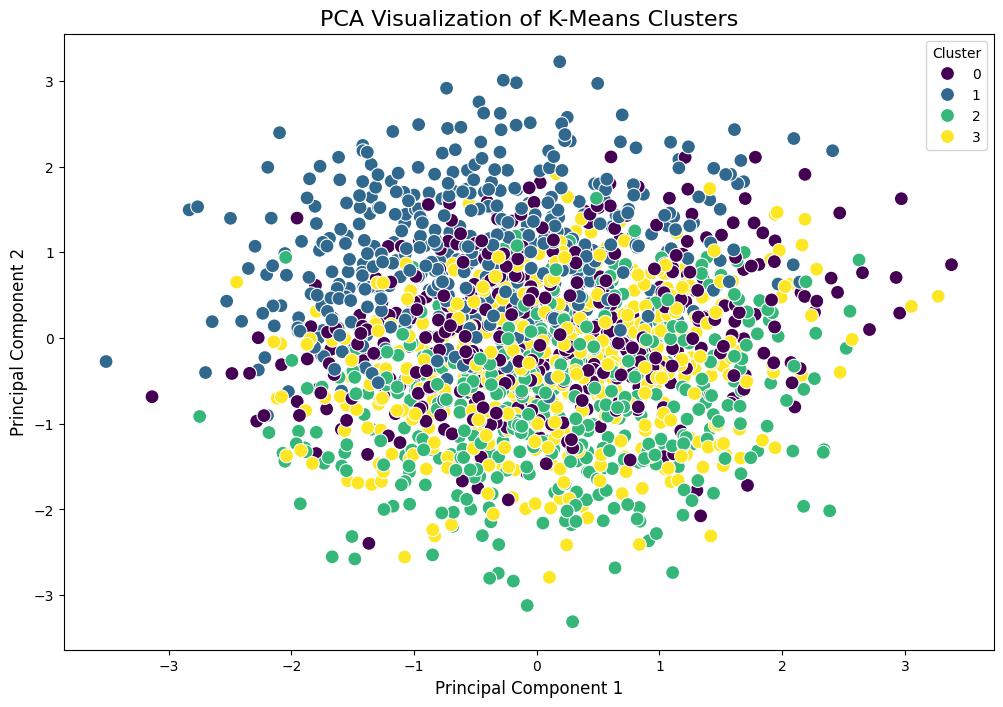

In [ ]:
# PCA SCATTER PLOT
# ===========================================

# Set figure size
plt.figure(figsize=(12,8))

# Create scatter plot
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

# Plot title
plt.title('PCA Visualization of K-Means Clusters', fontsize=16)

# X-axis label
plt.xlabel('Principal Component 1', fontsize=12)

# Y-axis label
plt.ylabel('Principal Component 2', fontsize=12)

# Show legend
plt.legend(title='Cluster')

# Show graph
plt.show()

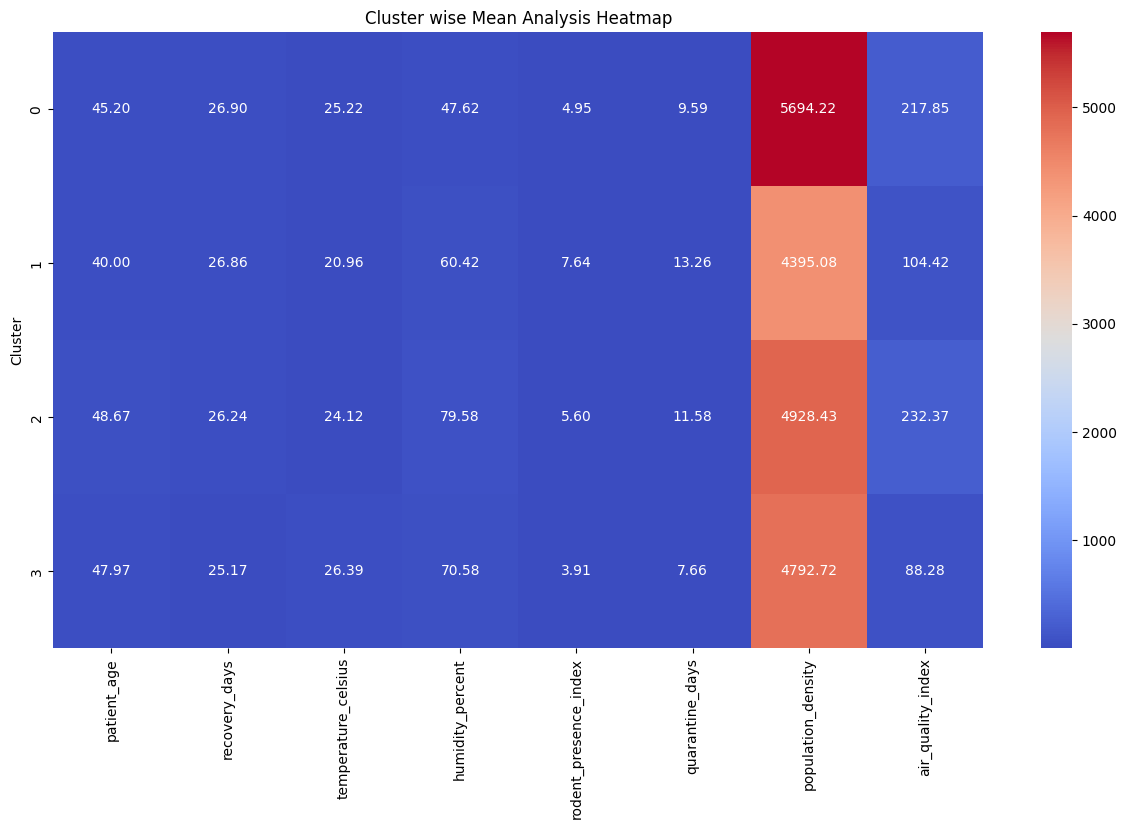

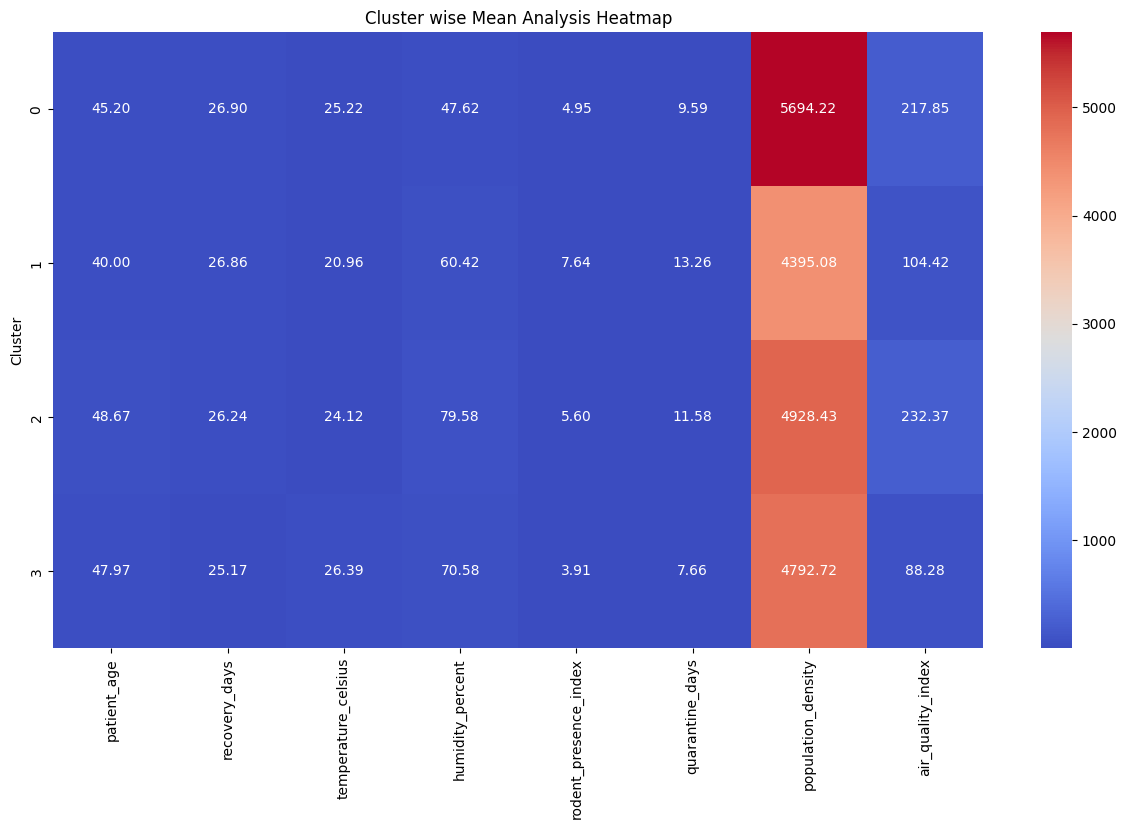

In [ ]:
# HEATMAP OF CLUSTER MEANS
# ===========================================

# Set figure size
plt.figure(figsize=(15,8))

# Create heatmap
sns.heatmap(
    cluster_mean,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# Title
plt.title('Cluster wise Mean Analysis Heatmap')

# Show graph
plt.show()# HEATMAP OF CLUSTER MEANS
# ===========================================

# Set figure size
plt.figure(figsize=(15,8))

# Create heatmap
sns.heatmap(
    cluster_mean,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# Title
plt.title('Cluster wise Mean Analysis Heatmap')

# Show graph
plt.show()

**Conclusion:**

The K-Means clustering algorithm successfully grouped the dataset into four distinct clusters based on patient, environmental, and population characteristics. PCA visualization showed a clear separation of clusters in two-dimensional space, indicating meaningful grouping patterns.

Cluster 2 recorded the highest average air_quality_index (232.37), with high humidity (79.58%) and moderate rodent presence (5.60). Cluster 0 also showed a high air_quality_index (217.85) and the highest population density (5694.22). In contrast, Cluster 3 had the lowest air_quality_index (88.28), along with the lowest rodent_presence_index (3.91) and quarantine_days (7.66). Cluster 1 had a moderate air_quality_index (104.42) but the highest rodent_presence_index (7.64) and quarantine_days (13.26).

The clustering results helping identify patterns related to air quality, population density, humidity, and rodent presence. Overall, K-Means effectively segmented the data into meaningful clusters, providing valuable insights for further analysis and decision-making.